In [1]:
!pip install pandas openpyxl -q
!pip install folium -q
!pip install geopy -q
!pip install opencage -q
!pip install scikit-learn -q
!pip install matplotlib -q


[notice] A new release of pip is available: 23.2.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 23.2.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 23.2.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 23.2.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 23.2.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 23.2.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [9]:
import pandas as pd
import warnings
import folium
import numpy as np
from sklearn.cluster import DBSCAN
from sklearn.metrics.pairwise import haversine_distances
from sklearn.cluster import DBSCAN
from sklearn.metrics.pairwise import haversine_distances
import matplotlib.colors as mcolors
from matplotlib import colormaps
import math
import branca
from folium import DivIcon


warnings.filterwarnings("ignore", category=UserWarning, module="openpyxl")

In [4]:
df = pd.read_excel("data/Reporte Histórico de Roturas - Surtigas.xlsx", sheet_name="Detalle Roturas Historico")
df.rename(columns={"LAT ": "LAT"}, inplace=True)
df_plano = df.dropna(subset=["LAT", "LONG"])

In [6]:
df_plano["Dimensión Rotura"] = df_plano["Dimensión Rotura"].replace("Minimo", "Mínimo")
df_plano["Dimensión Rotura"] = df_plano["Dimensión Rotura"].fillna("NO APLICA")

from fractions import Fraction

def diametro_a_numero(valor):
    valor = str(valor).strip()
    
    try:
        # caso: "1 1/2"
        if " " in valor:
            entero, fraccion = valor.split()
            return float(entero) + float(Fraction(fraccion))
        
        # caso: "1/2"
        if "/" in valor:
            return float(Fraction(valor))
        
        # caso: número normal "2", "3"
        return float(valor)
    
    except:
        return None
    
df_plano["Diametro"] = df["Diametro"].astype(str)
df_plano["Diametro"] = df_plano["Diametro"].replace("2026-04-03 00:00:00", "3/4")
df_plano["Diametro_num"] = df_plano["Diametro"].apply(diametro_a_numero)

df_plano["Orgen_data"] = str("Probado")

import json

with open("mapeo_categorias.json", "r", encoding="utf-8") as f:
    data = json.load(f)

mapeo = data["mapeo"]

df_plano["categoria_final"] = df_plano["TIPO"].map(mapeo)

In [67]:

def agregar_leyenda(mapa, beta, n_clusters, score_min, score_max):
    """
    Agrega una leyenda flotante al mapa Folium con:
    - Escala de colores YlOrRd
    - Parámetros actuales (β, clusters encontrados)
    - Referencia de opacidad
    """
    # ── Genera la barra de color en HTML usando matplotlib ────────────────
    import matplotlib.pyplot as plt
    import matplotlib.colors as mcolors
    import numpy as np
    import base64
    from io import BytesIO

    fig, ax = plt.subplots(figsize=(3, 0.35))
    fig.patch.set_alpha(0)
    cmap = plt.cm.get_cmap("YlOrRd")
    norm = mcolors.Normalize(vmin=0, vmax=1)
    cb   = plt.colorbar(
        plt.cm.ScalarMappable(norm=norm, cmap=cmap),
        cax=ax, orientation="horizontal"
    )
    cb.set_ticks([0, 0.25, 0.5, 0.75, 1.0])
    cb.set_ticklabels(["0.0\nBajo", "0.25", "0.50", "0.75", "1.0\nAlto"])
    cb.ax.tick_params(labelsize=7, colors="#333")
    plt.tight_layout(pad=0.1)

    # Convierte la figura a base64 para embeber en HTML
    buf = BytesIO()
    plt.savefig(buf, format="png", dpi=120, bbox_inches="tight",
                transparent=True)
    plt.close()
    buf.seek(0)
    img_b64 = base64.b64encode(buf.read()).decode("utf-8")

    # ── HTML de la leyenda ────────────────────────────────────────────────
    legend_html = f"""
    <div style="
        position: fixed;
        bottom: 40px; right: 15px;
        z-index: 1000;
        background: rgba(255,255,255,0.05);
        border: 1px solid #ccc;
        border-radius: 8px;
        padding: 10px 14px;
        font-family: Arial, sans-serif;
        font-size: 12px;
        color: #333;
        box-shadow: 2px 2px 6px rgba(0,0,0,0.2);
        min-width: 200px;
    ">
        <b style="font-size:13px;">🗺️ Score Final</b>
        <hr style="margin:5px 0; border-color:#ddd;">

        <!-- Barra de color -->
        <img src="data:image/png;base64,{img_b64}"
             style="width:100%; margin: 4px 0;">

        <!-- Parámetros -->
        <div style="margin-top:6px; line-height:1.7;">
            <b>β</b> = {beta}
            &nbsp;·&nbsp;
            <span style="color:#888">
                {round(beta*100)}% variables + {round((1-beta)*100)}% densidad
            </span><br>
            <b>Clusters</b>: {n_clusters}<br>
            <b>Rango score</b>: [{score_min:.2f} – {score_max:.2f}]
        </div>
        <!-- Referencia de opacidad -->
        <hr style="margin:6px 0; border-color:#ddd;">
        <div style="font-size:11px; color:#666;">
            Opacidad del círculo = intensidad del score
        </div>
        <div style="display:flex; gap:4px; margin-top:4px; align-items:center;">
            <div style="width:28px;height:14px;background:#ffffb2;
                        opacity:0.5;border:1px solid #ffffb2;
                        border-radius:3px;"></div>
            <span style="font-size:10px;">Bajo</span>
            <div style="width:28px;height:14px;background:#fd8d3c;
                        opacity:0.5;border:1px solid #fd8d3c;
                        border-radius:3px; margin-left:8px;"></div>
            <span style="font-size:10px;">Medio</span>
            <div style="width:28px;height:14px;background:#f03b20;
                        opacity:0.85;border:1px solid #f03b20;
                        border-radius:3px; margin-left:8px;"></div>
            <span style="font-size:10px;">Alto</span>
        </div>

        <!-- ✅ NUEVO: Indicativo de Riesgo tubería -->
        <hr style="margin:6px 0; border-color:#ddd;">
        <b style="font-size:12px;">🚧 Riesgo Tubería</b>
        <div style="margin-top:5px; display:flex; flex-direction:column; gap:4px;">
            
            <div style="display:flex; align-items:center; gap:8px;">
                <svg width="20" height="20" viewBox="0 0 100 100">
                    <polygon points="50,5 95,90 5,90" fill="#e74c3c" stroke="#c0392b" stroke-width="5"/>
                    <polygon points="50,18 85,83 15,83" fill="none" stroke="white" stroke-width="3"/>
                    <ellipse cx="50" cy="35" rx="12" ry="7" fill="white"/>
                    <rect x="40" y="38" width="20" height="4" fill="white"/>
                    <rect x="44" y="44" width="12" height="18" rx="3" fill="white"/>
                    <line x1="56" y1="48" x2="68" y2="60" stroke="white" stroke-width="3"/>
                    <line x1="47" y1="62" x2="44" y2="76" stroke="white" stroke-width="3"/>
                    <line x1="53" y1="62" x2="56" y2="76" stroke="white" stroke-width="3"/>
                </svg>
                <span style="font-size:11px;">Muy Alto / Alto</span>
            </div>

            <div style="display:flex; align-items:center; gap:8px;">
                <svg width="20" height="20" viewBox="0 0 100 100">
                    <polygon points="50,5 95,90 5,90" fill="#f39c12" stroke="#d68910" stroke-width="5"/>
                    <polygon points="50,18 85,83 15,83" fill="none" stroke="white" stroke-width="3"/>
                    <ellipse cx="50" cy="35" rx="12" ry="7" fill="white"/>
                    <rect x="40" y="38" width="20" height="4" fill="white"/>
                    <rect x="44" y="44" width="12" height="18" rx="3" fill="white"/>
                    <line x1="56" y1="48" x2="68" y2="60" stroke="white" stroke-width="3"/>
                    <line x1="47" y1="62" x2="44" y2="76" stroke="white" stroke-width="3"/>
                    <line x1="53" y1="62" x2="56" y2="76" stroke="white" stroke-width="3"/>
                </svg>
                <span style="font-size:11px;">Medio</span>
            </div>

            <div style="display:flex; align-items:center; gap:8px;">
                <svg width="20" height="20" viewBox="0 0 100 100">
                    <polygon points="50,5 95,90 5,90" fill="#27ae60" stroke="#1e8449" stroke-width="5"/>
                    <polygon points="50,18 85,83 15,83" fill="none" stroke="white" stroke-width="3"/>
                    <ellipse cx="50" cy="35" rx="12" ry="7" fill="white"/>
                    <rect x="40" y="38" width="20" height="4" fill="white"/>
                    <rect x="44" y="44" width="12" height="18" rx="3" fill="white"/>
                    <line x1="56" y1="48" x2="68" y2="60" stroke="white" stroke-width="3"/>
                    <line x1="47" y1="62" x2="44" y2="76" stroke="white" stroke-width="3"/>
                    <line x1="53" y1="62" x2="56" y2="76" stroke="white" stroke-width="3"/>
                </svg>
                <span style="font-size:11px;">Bajo / Muy Bajo</span>
            </div>
        </div>
    </div>
    """
    mapa.get_root().html.add_child(folium.Element(legend_html))
    return mapa





✅ Clusters: 38  |  Ruido: 407 puntos


/tmp/ipykernel_42486/295987496.py:17: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("YlOrRd")



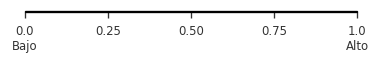

In [68]:
# ══════════════════════════════════════════════════════════════════════════════
# 0. PARÁMETROS GLOBALES — modifica aquí libremente
# ══════════════════════════════════════════════════════════════════════════════
BETA        = 0.5    # 0 = solo densidad | 1 = solo variables | 0.5 = equilibrio
RADIO_KM    = 0.5    # vecindad DBSCAN en km
MIN_PUNTOS  = 5      # mínimo de puntos para formar cluster

# ── Dimensión Rotura: Total y NO APLICA con igual peso máximo ─────────────────
# Total     = rotura completa          → máxima gravedad
# NO APLICA = evento sin rotura física → igual de relevante operativamente
# Parcial   = daño intermedio
# Mínima    = daño superficial
MAP_DIM_ROTURA = {
    "Total":     1.00,
    "NO APLICA": 1.00,
    "Parcial":   0.50,
    "Mínima":    0.15,
}

# ── TERCERO/OBRA: TERCERO es 1.5× más relevante que OBRA ─────────────────────
# Normalizando sobre el máximo (1.5): OBRA = 0.667, TERCERO = 1.0
_max_to = 1.5
MAP_TERCERO_OBRA = {
    "OBRA":    round(1.0 / _max_to, 4),   # ≈ 0.6667
    "TERCERO": round(1.5 / _max_to, 4),   # = 1.0000
}

# ── TIPO: severidad descendente (posición 1 = más grave) ─────────────────────
_tipos_ordenados = [
    "Excavación",                              # 1.000
    "Alcantarillado y acueducto",              # 0.667
    "Pavimentación",                           # 0.889
    "Instalaciones ",                          # 0.778
    "Obras civiles y construcción",            # 0.556
    "Limpieza",                                # 0.444
    "Daños",                                   # 0.333
    "Instalación de tuberías y ductos eléctricos", # 0.222
    "Nivelación de terreno y calles",          # 0.111
    "Otros",                                   # 0.000
]
n_t = len(_tipos_ordenados)
MAP_TIPO = {
    tipo: round(1.0 - i / (n_t - 1), 4)
    for i, tipo in enumerate(_tipos_ordenados)
}

# ── Probado / Inferido: confianza del dato ────────────────────────────────────
MAP_CERTEZA = {
    "Probado":  1.00,
    "Inferido": 0.20,
}

# ══════════════════════════════════════════════════════════════════════════════
# 2. PESOS DE CADA VARIABLE EN EL SCORE DEL PUNTO   (deben sumar 1.0)
# ══════════════════════════════════════════════════════════════════════════════
PESOS = {
    "diametro":    0.25,
    "dim_rotura":  0.25,
    "tercero_obra":0.25,
    "tipo":        0.25,
}
assert abs(sum(PESOS.values()) - 1.0) < 1e-9, "⚠️ Los pesos deben sumar 1.0"

# ══════════════════════════════════════════════════════════════════════════════
# 3. SCORE POR PUNTO
# ══════════════════════════════════════════════════════════════════════════════
def calcular_score_punto(row):
    """
    Recibe una fila del DataFrame y devuelve un score en [0, 1].
    Ajusta los nombres de columna según tu DataFrame real.
    """
    s_diam  = row.get("Diametro_num", 0.0)
    s_rot   = MAP_DIM_ROTURA .get(str(row["Dimensión Rotura"]),    0.0)
    s_to    = MAP_TERCERO_OBRA.get(str(row["TERCERO/OBRA PUBLICA"]), 0.0)
    s_tipo  = MAP_TIPO       .get(str(row["categoria_final"]),         0.0)
    s_cert  = MAP_CERTEZA    .get(str(row["Orgen_data"]),      0.0)

    return (
        s_cert * (PESOS["diametro"] * s_diam  +
        PESOS["dim_rotura"] * s_rot   +
        PESOS["tercero_obra"] * s_to    +
        PESOS["tipo"] * s_tipo)
    )

df_plano["score_punto"] = df_plano.apply(calcular_score_punto, axis=1)

# ══════════════════════════════════════════════════════════════════════════════
# 4. DBSCAN — detección de clusters geográficos
# ══════════════════════════════════════════════════════════════════════════════
coords_rad = np.radians(df_plano[["LAT", "LONG"]].values)

db = DBSCAN(
    eps=RADIO_KM / 6371.0,
    min_samples=MIN_PUNTOS,
    algorithm="ball_tree",
    metric="haversine"
).fit(coords_rad)

df_plano["cluster"] = db.labels_
n_clusters = df_plano["cluster"].max() + 1
n_ruido    = (df_plano["cluster"] == -1).sum()
print(f"✅ Clusters: {n_clusters}  |  Ruido: {n_ruido} puntos")

# ══════════════════════════════════════════════════════════════════════════════
# 5. SCORE POR CLUSTER
# ══════════════════════════════════════════════════════════════════════════════
max_puntos = df_plano[df_plano["cluster"] >= 0].groupby("cluster").size().max()

resumen_clusters = []
for cid in range(n_clusters):
    grupo = df_plano[df_plano["cluster"] == cid]
    n     = len(grupo)

    centro_lat = grupo.LAT.mean()
    centro_lon = grupo.LONG.mean()
    ciudad = grupo.Ciudad.unique()[0]

    # Radio geográfico real (huella física)
    puntos_rad = np.radians(grupo[["LAT", "LONG"]].values)
    centro_rad = np.radians([[centro_lat, centro_lon]])
    dists_m    = haversine_distances(puntos_rad, centro_rad)[:, 0] * 6371000
    radio_m    = max(dists_m.max() * 1.15, 300)   # +15% margen, mín 300 m

    # Score de variables: promedio del cluster (independiente del tamaño)
    score_vars    = grupo["score_punto"].mean()

    # Score de densidad: n relativo al cluster más denso
    score_densidad = n / max_puntos

    # Score final ponderado por β
    score_final = BETA * score_vars + (1 - BETA) * score_densidad

    resumen_clusters.append({
        "cid":        cid,
        "n":          n,
        "Ciudad":     ciudad,
        "lat":        centro_lat,
        "lon":        centro_lon,
        "radio_m":    radio_m,
        "score_vars": score_vars,
        "score_dens": score_densidad,
        "score_final":score_final,
    })

df_clusters = pd.DataFrame(resumen_clusters)

# ══════════════════════════════════════════════════════════════════════════════
# 6. COLORMAP continuo YlOrRd  →  score_final [0,1] a color hex
# ══════════════════════════════════════════════════════════════════════════════
cmap = colormaps["YlOrRd"]

def score_a_color(score):
    r, g, b, _ = cmap(float(score))
    return mcolors.to_hex((r, g, b))

def score_a_opacidad(score, op_min=0.15, op_max=0.75):
    """La opacidad del relleno respira con el score_final."""
    return op_min + (op_max - op_min) * float(score)

# ══════════════════════════════════════════════════════════════════════════════
# 7. MAPA FOLIUM
# ══════════════════════════════════════════════════════════════════════════════
mapa = folium.Map(
    location=[df_plano.LAT.mean(), df_plano.LONG.mean()],
    tiles="CartoDB positron",
    zoom_start=12
)

# ── Círculos de clusters ───────────────────────────────────────────────────
for _, c in df_clusters.iterrows():
    color   = score_a_color(c.score_final)
    opacidad = score_a_opacidad(c.score_final)

    # Círculo translúcido principal
    folium.Circle(
        location=[c.lat, c.lon],
        radius=c.radio_m,
        color=color,
        weight=2.5,
        fill=True,
        fill_color=color,
        fill_opacity=opacidad,
        popup=folium.Popup(
            f"<b>Zona {int(c.cid)+1}</b><br>"
            f"Puntos: {int(c.n)}<br>"
            f"Score variables: {c.score_vars:.3f}<br>"
            f"Score densidad: {c.score_dens:.3f}<br>"
            f"<b>Score final (β={BETA}): {c.score_final:.3f}</b><br>"
            f"Radio: {c.radio_m:.0f} m<br>"
            f"Área: {math.pi * (c.radio_m/1000)**2:.1f} km2",
            max_width=220
        ),
        tooltip=f"Zona {int(c.cid)+1} · score {c.score_final:.2f} · {int(c.n)} pts"
    ).add_to(mapa)

    # Borde punteado interior
    folium.Circle(
        location=[c.lat, c.lon],
        radius=c.radio_m,
        color=color,
        weight=1,
        fill=False,
        dash_array="6 4",
    ).add_to(mapa)

    # Centroide
    folium.CircleMarker(
        location=[c.lat, c.lon],
        radius=5,
        color="white",
        weight=1.5,
        fill=True,
        fill_color=color,
        fill_opacity=1.0,
        tooltip=f"Centroide zona {int(c.cid)+1}"
    ).add_to(mapa)

# ── Puntos individuales ────────────────────────────────────────────────────
for _, row in df_plano.iterrows():
    es_ruido = row["cluster"] == -1
    pt_color = score_a_color(row["score_punto"]) if not es_ruido else "#7f8c8d"
    folium.CircleMarker(
        location=[row.LAT, row.LONG],
        radius=3,
        color="white",
        weight=0.5,
        fill=True,
        fill_color=pt_color,
        fill_opacity=0.85 if not es_ruido else 0.4,
        tooltip=(
            f"Zona {int(row['cluster'])+1} · score {row['score_punto']:.2f}"
            if not es_ruido else "Punto aislado"
        )
    ).add_to(mapa)

# ── Úsala así, justo antes de mostrar el mapa ────────────────────────────────
mapa = agregar_leyenda(
    mapa,
    beta       = BETA,
    n_clusters = n_clusters,
    score_min  = df_clusters["score_final"].min(),
    score_max  = df_clusters["score_final"].max(),
)

#mapa.save("mapa_obra.html")
mapa

In [55]:
df["Nivel de riesgo"].value_counts()

Nivel de riesgo
Medio       47
Muy Bajo    30
Bajo        17
Muy alto     6
Alto         2
Name: count, dtype: int64

In [69]:
RISK_COLORS = {
    'muy alto':     {'color': '#e74c3c', 'border': '#c0392b'},  # Rojo
    'alto':         {'color': '#e74c3c', 'border': '#c0392b'},  # Rojo
    'medio':        {'color': '#f39c12', 'border': '#d68910'},  # Amarillo/Naranja
    'bajo':         {'color': '#27ae60', 'border': '#1e8449'},  # Verde
    'muy bajo':     {'color': '#27ae60', 'border': '#1e8449'},  # Verde
}

In [70]:
import unicodedata
import re

def normalizar_riesgo(texto: str) -> str:
    if not isinstance(texto, str):
        texto = str(texto)
    texto = texto.strip()
    texto = re.sub(r'\s+', ' ', texto)
    texto = texto.lower()
    texto = unicodedata.normalize('NFD', texto)
    texto = ''.join(c for c in texto if unicodedata.category(c) != 'Mn')
    return texto

In [71]:
def icono_obra(riesgo: str, size: int = 36) -> DivIcon:
    """
    Genera un DivIcon con triángulo de advertencia estilo obra vial.
    riesgo: 'alto' | 'moderado' | 'bajo'  (insensible a mayúsculas)
    """
    key    = normalizar_riesgo(riesgo)
    colors = RISK_COLORS.get(key, RISK_COLORS['medio'])
    fill   = colors['color']
    border = colors['border']

    # SVG de triángulo con ícono de persona trabajando (⚠ + obrero)
    svg = f"""
    <svg xmlns="http://www.w3.org/2000/svg" width="{size}" height="{size}" viewBox="0 0 100 100">
      <!-- Triángulo de fondo -->
      <polygon points="50,5 95,90 5,90"
               fill="{fill}" stroke="{border}" stroke-width="5"/>
      <!-- Borde blanco interior -->
      <polygon points="50,18 85,83 15,83"
               fill="none" stroke="white" stroke-width="3"/>
      <!-- Signo de exclamación o ícono obrero -->
      <!-- Casco -->
      <ellipse cx="50" cy="35" rx="12" ry="7" fill="white"/>
      <rect x="40" y="38" width="20" height="4" fill="white"/>
      <!-- Cuerpo -->
      <rect x="44" y="44" width="12" height="18" rx="3" fill="white"/>
      <!-- Pala -->
      <line x1="56" y1="48" x2="68" y2="60" stroke="white" stroke-width="3"/>
      <ellipse cx="70" cy="62" rx="5" ry="4" fill="white" transform="rotate(-45,70,62)"/>
      <!-- Piernas -->
      <line x1="47" y1="62" x2="44" y2="76" stroke="white" stroke-width="3"/>
      <line x1="53" y1="62" x2="56" y2="76" stroke="white" stroke-width="3"/>
    </svg>
    """

    return DivIcon(
        html=svg,
        icon_size=(size, size),
        icon_anchor=(size // 2, size),   # ancla en la punta inferior del triángulo
        popup_anchor=(0, -size),
    )


def agregar_puntos_riesgo(mapa: folium.Map, df) -> folium.Map:
    """
    Agrega los puntos de riesgo al mapa existente.
    
    df debe tener columnas: 'lat', 'long', 'Riesgo'
    y opcionalmente cualquier columna adicional para el popup.
    """
    grupo = folium.FeatureGroup(name="Obras / Riesgo tuberia", show=True)

    for _, row in df.iterrows():
        riesgo = str(row['Nivel de riesgo'])
        
        # Popup con información del punto
        popup_html = f"""
        <div style="font-family:Arial; min-width:140px;">
            <b>Riesgo:</b> {riesgo}<br>
            <b>Lat:</b> {row['y']:.5f}<br>
            <b>Lon:</b> {row['x']:.5f}
        </div>
        """
        
        folium.Marker(
            location=[row['y'], row['x']],
            icon=icono_obra(riesgo,15),
            popup=folium.Popup(popup_html, max_width=200),
            tooltip=f"Riesgo {riesgo}",
        ).add_to(grupo)

    grupo.add_to(mapa)
    
    # Control de capas para activar/desactivar el grupo
    #folium.LayerControl(collapsed=False).add_to(mapa)
    
    return mapa

In [72]:
#mapa = folium.Map(
#    location=[df_plano.LAT.mean(), df_plano.LONG.mean()],
#    tiles="CartoDB positron",
#    zoom_start=12
#)  # ✅ siempre reinicia el mapa

mapa_riesgos = agregar_puntos_riesgo(mapa, df)

folium.LayerControl(collapsed=False).add_to(mapa) # ✅ se agrega solo una vez al final

mapa.save("mapa_riesgo.html")

In [44]:
df['Nivel de riesgo'].value_counts()

Nivel de riesgo
Medio       47
Muy Bajo    30
Bajo        17
Muy alto     6
Alto         2
Name: count, dtype: int64